# 07 · Risk scoring & KPIs

`risk = 100 x (0.40 anomaly + 0.30 model probability + 0.20 expected severity + 0.10 rule flags)`, computed on the out-of-sample test split. Severity uses the multiclass model's *predicted* class probabilities - never the true label. IP-level risk is replaced by segment-level risk (proto/service/state). See `src/risk.py` for the weight justification.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
SRC = Path.cwd().parent / 'src' if (Path.cwd().parent / 'src').exists() else Path.cwd() / 'src'
sys.path.insert(0, str(SRC))
import pandas as pd, json
from IPython.display import Image, Markdown, display
from config import FIG_DIR, METRICS_DIR, REPORTS_DIR, EXPORT_DIR
pd.set_option('display.max_columns', 60, 'display.width', 200)
def show(name, width=900):
    display(Image(filename=str(FIG_DIR / f'{name}.png'), width=width))

In [2]:
import risk
res = risk.run()


PHASE 8 - RISK SCORING
Rule thresholds (normal train): rate>333,333, ct_srv_src>35, ct_dst_src_ltm>35, common protos=['arp', 'ospf', 'tcp', 'udp']


             flows  true_attacks   avg_risk  attack_precision  pct_flows
risk_bucket                                                             
Low          14746           166  13.804447            0.0113      17.91
Medium       18308          1996  36.189220            0.1090      22.24
High         12408          6520  61.275678            0.5255      15.07
Critical     36870         36650  83.278071            0.9940      44.78
Rule flag rates by label:
        flag_high_pkt_rate  flag_rare_proto  flag_burst_context
label                                                         
0                   0.011            0.001               0.008
1                   0.040            0.179               0.099


Top risky segments:
          segment  flows  mean_risk  max_risk  critical_flows segment_risk_bucket
     udp/dns/INT  18263      82.48     88.63           18235            Critical
    tcp/http/FIN   8270      60.08     88.84            3524                High
   unas/none/INT   3515      87.14     91.49            3515            Critical
    udp/none/INT   6362      64.89     88.83            1871                High
    tcp/none/FIN  25629      35.00     86.50            1587              Medium
    tcp/smtp/FIN   1836      65.34     86.73            1201                High
     tcp/ftp/FIN   1541      60.92     86.78             524                High
   ospf/none/INT    524      84.55     86.55             523            Critical
tcp/ftp-data/FIN   1390      45.46     86.40             445              Medium
    tcp/pop3/FIN    420      84.07     86.67             417            Critical
                                      kpi                                     value    u

 - flow_risk / segment_risk loaded into the database, risk views created
Risk score vs true label: {'roc_auc': 0.9733, 'pr_auc': 0.9805}


In [3]:
pd.DataFrame(res['bucket_distribution'])

,risk_bucket,flows,true_attacks,avg_risk,attack_precision,pct_flows
0,Low,14746,166,13.804447,0.0113,17.91
1,Medium,18308,1996,36.189220,0.1090,22.24
2,High,12408,6520,61.275678,0.5255,15.07
3,Critical,36870,36650,83.278071,0.9940,44.78


In [4]:
pd.DataFrame(res['top_segments'])[['segment','flows','mean_risk','max_risk','critical_flows','segment_risk_bucket']]

,segment,flows,mean_risk,max_risk,critical_flows,segment_risk_bucket
0,udp/dns/INT,18263,82.48,88.63,18235,Critical
1,tcp/http/FIN,8270,60.08,88.84,3524,High
2,unas/none/INT,3515,87.14,91.49,3515,Critical
3,udp/none/INT,6362,64.89,88.83,1871,High
4,tcp/none/FIN,25629,35.00,86.50,1587,Medium
5,tcp/smtp/FIN,1836,65.34,86.73,1201,High
6,tcp/ftp/FIN,1541,60.92,86.78,524,High
7,ospf/none/INT,524,84.55,86.55,523,Critical
8,tcp/ftp-data/FIN,1390,45.46,86.40,445,Medium
9,tcp/pop3/FIN,420,84.07,86.67,417,Critical


In [5]:
pd.read_csv(METRICS_DIR / 'kpis.csv')

,kpi,value,unit
0,Total flows (train+test),257673,count
1,Attack flows,164673,count
2,Attack rate %,63.91,percent
3,Flows risk-scored (test split),82332,count
4,Critical-risk flows,36870,count
5,High-risk flows,12408,count
6,Critical + High share %,59.85,percent
7,High/Critical-risk segments,139,count
8,Top attack type,Generic,text
9,Top attack type flows,58871,count


## Power BI previews
Generated by `src/powerbi.py` (`powerbi/previews/`).


PHASE 10 - POWER BI PREPARATION


   kpis: 19 rows
   dim_attack_type: 10 rows
   attack_by_type: 10 rows


   attack_by_duration_bin: 59 rows
   protocol_service_matrix: 965 rows
   attack_by_state: 51 rows
   top_risky_segments: 50 rows
   risk_bucket_distribution: 4 rows


   model_metrics: 7 rows
   model_metrics_multiclass: 3 rows
   per_class_report: 10 rows
   feature_importance: 30 rows


   recommendations: 8 rows
   confusion_matrix_binary: 4 rows


   flow_sample: 82,332 rows


   previews saved to C:\Users\anmol\OneDrive\Desktop\project 1\powerbi\previews


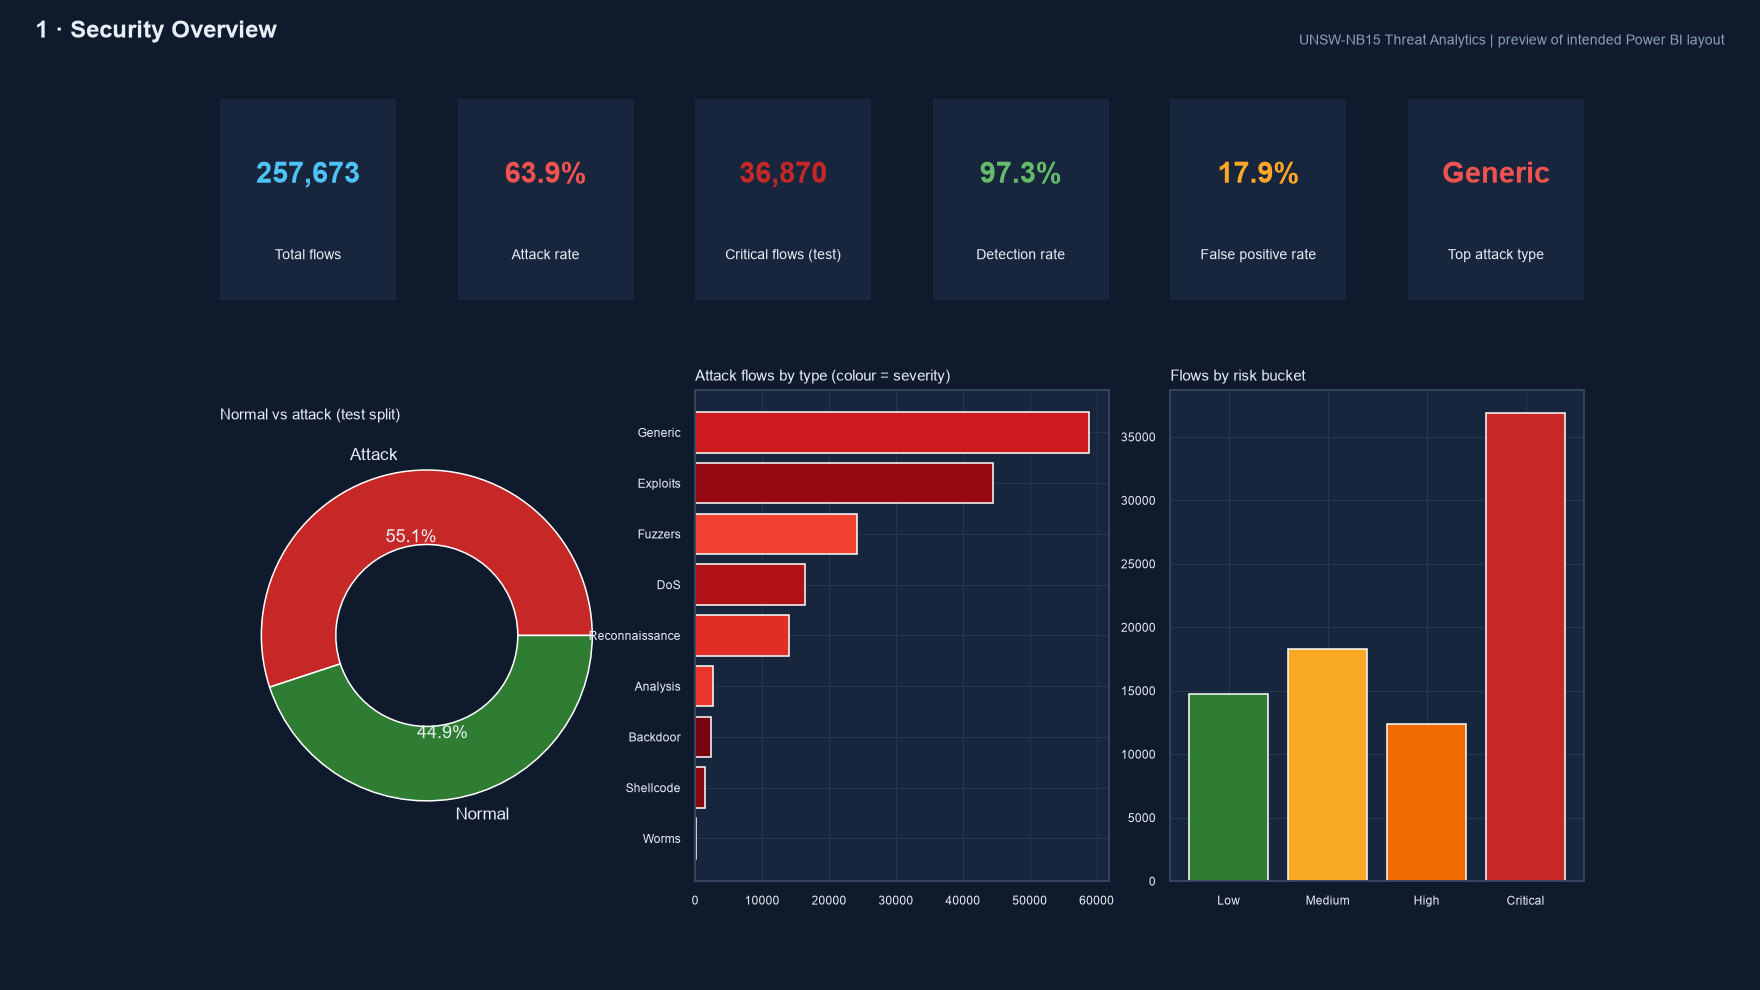

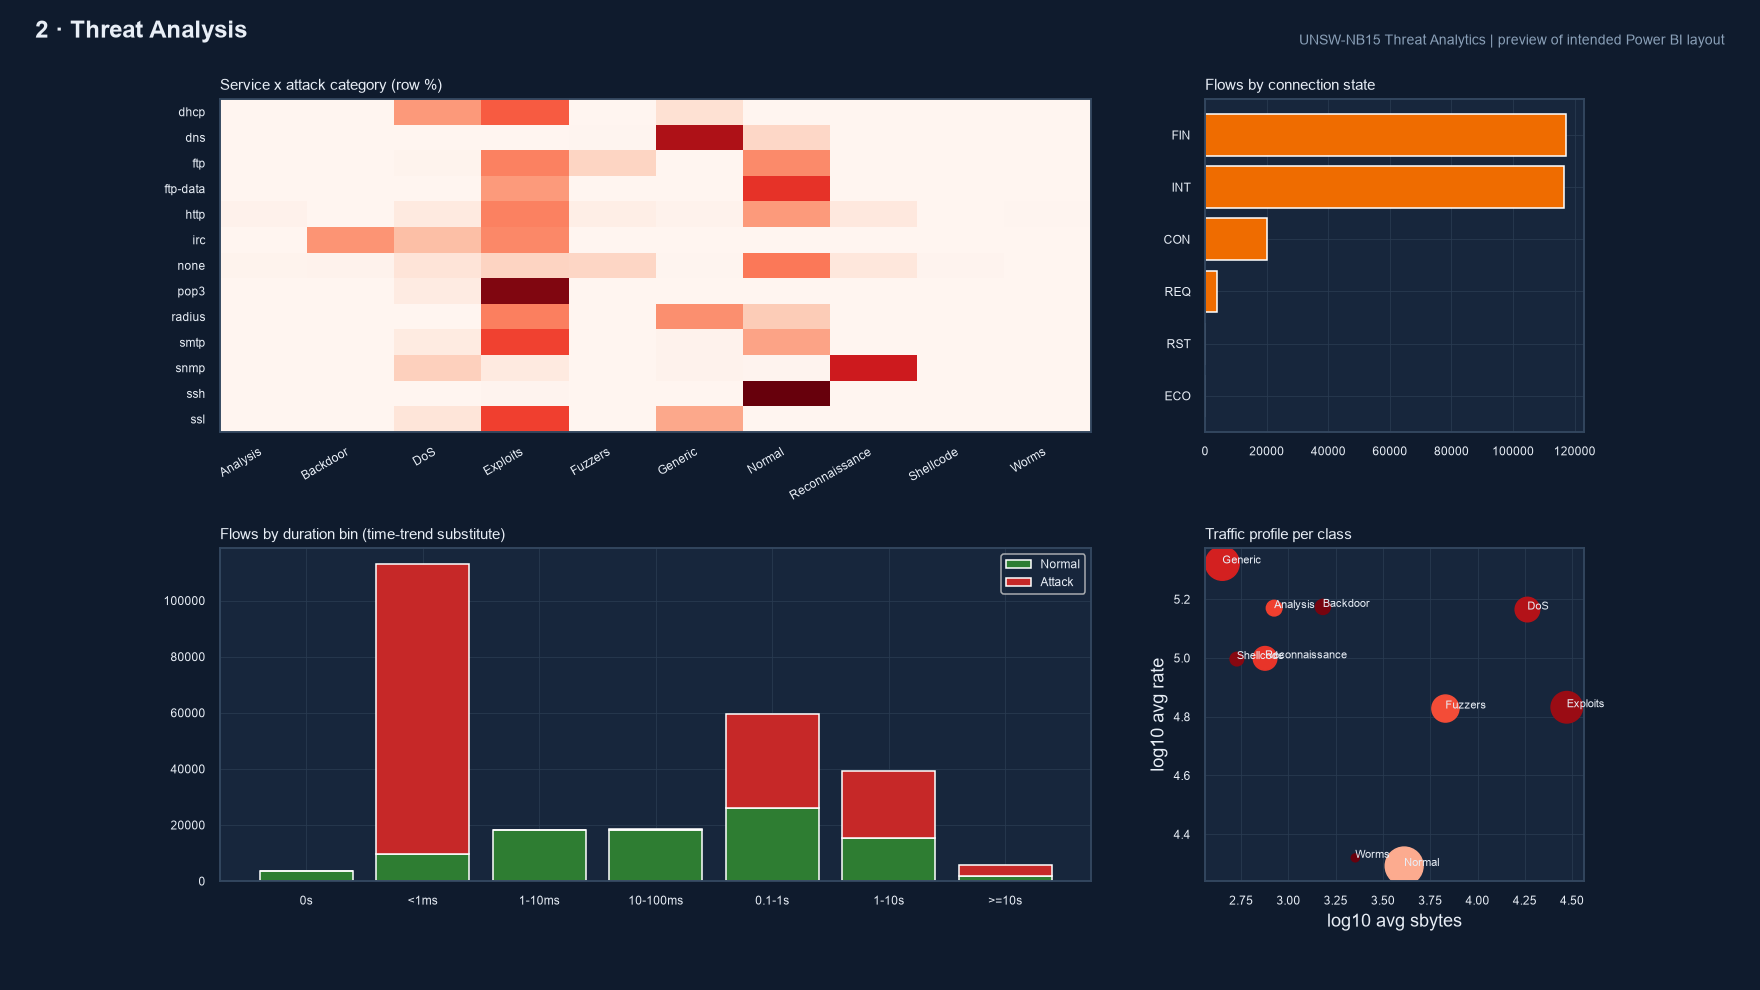

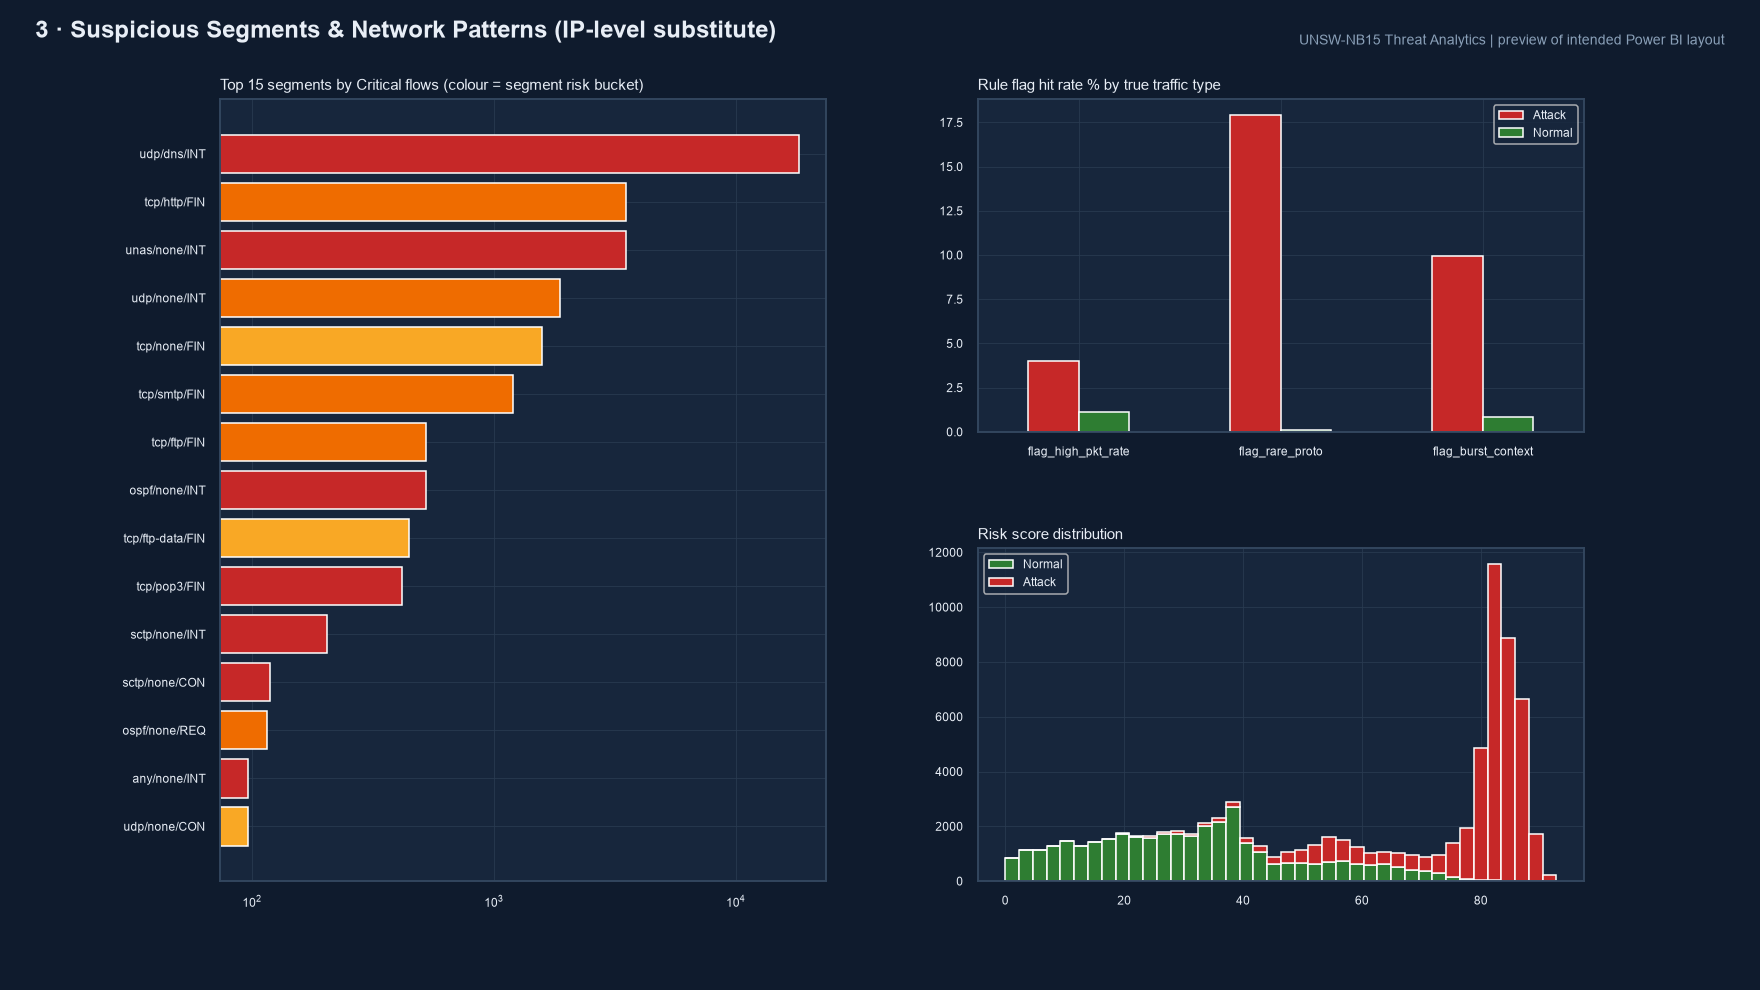

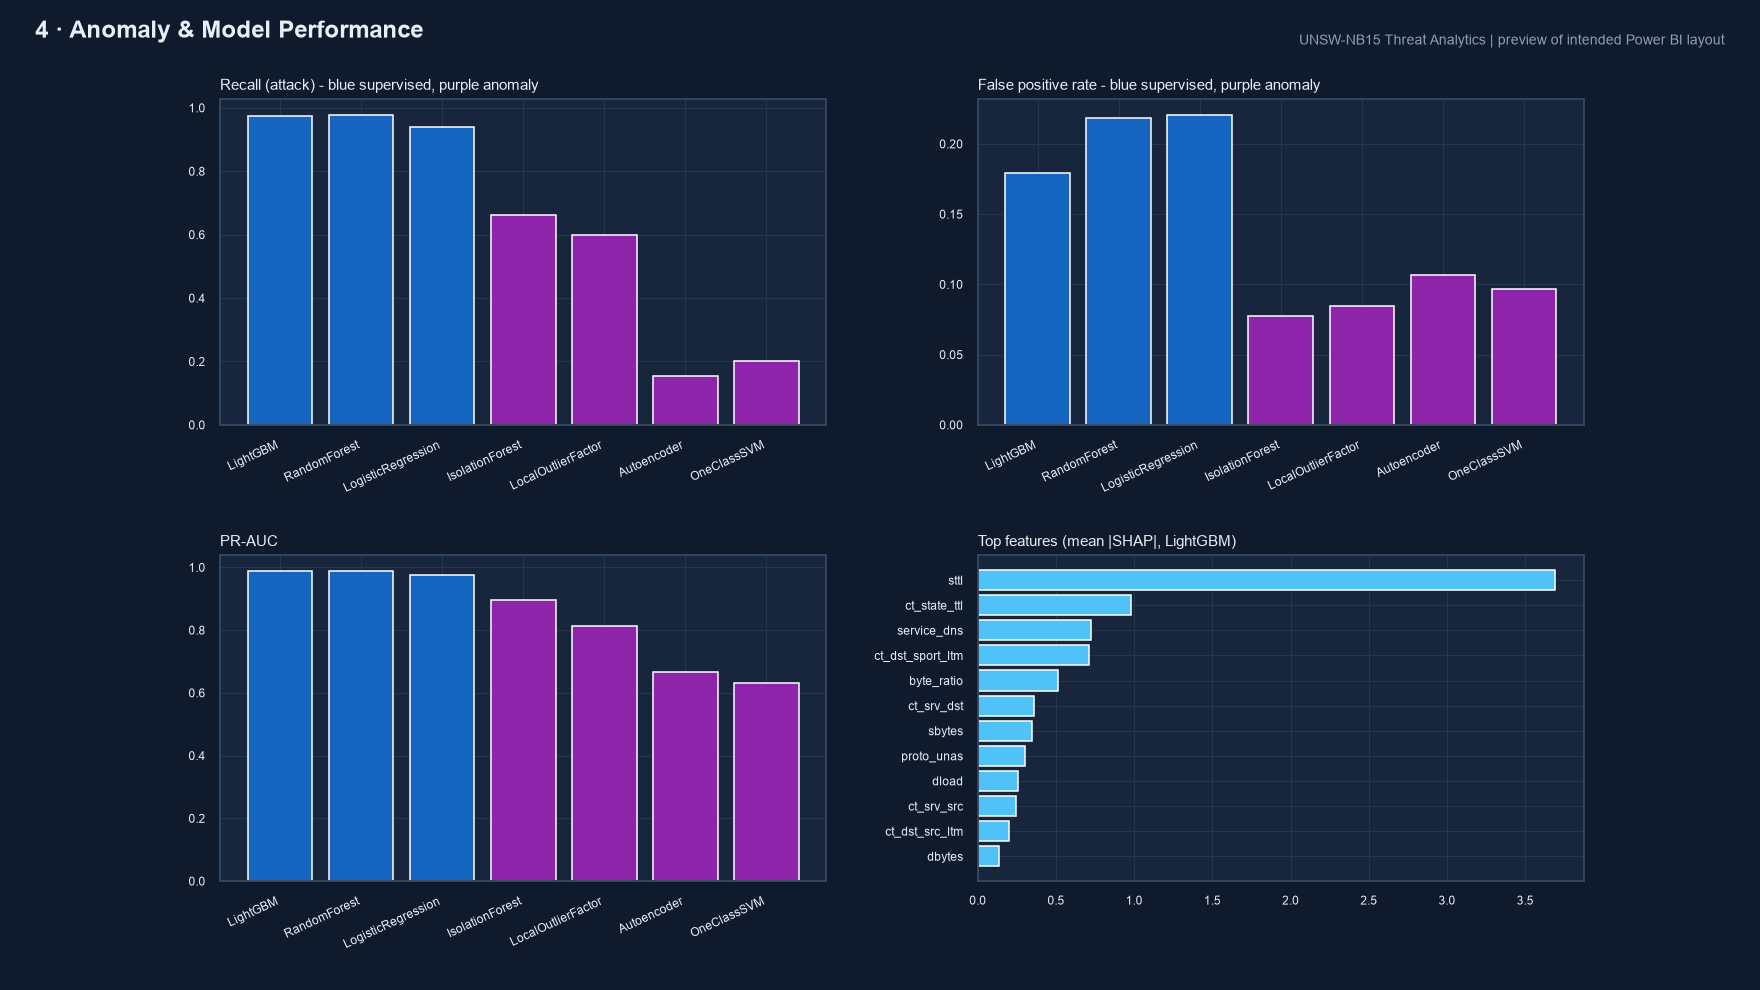

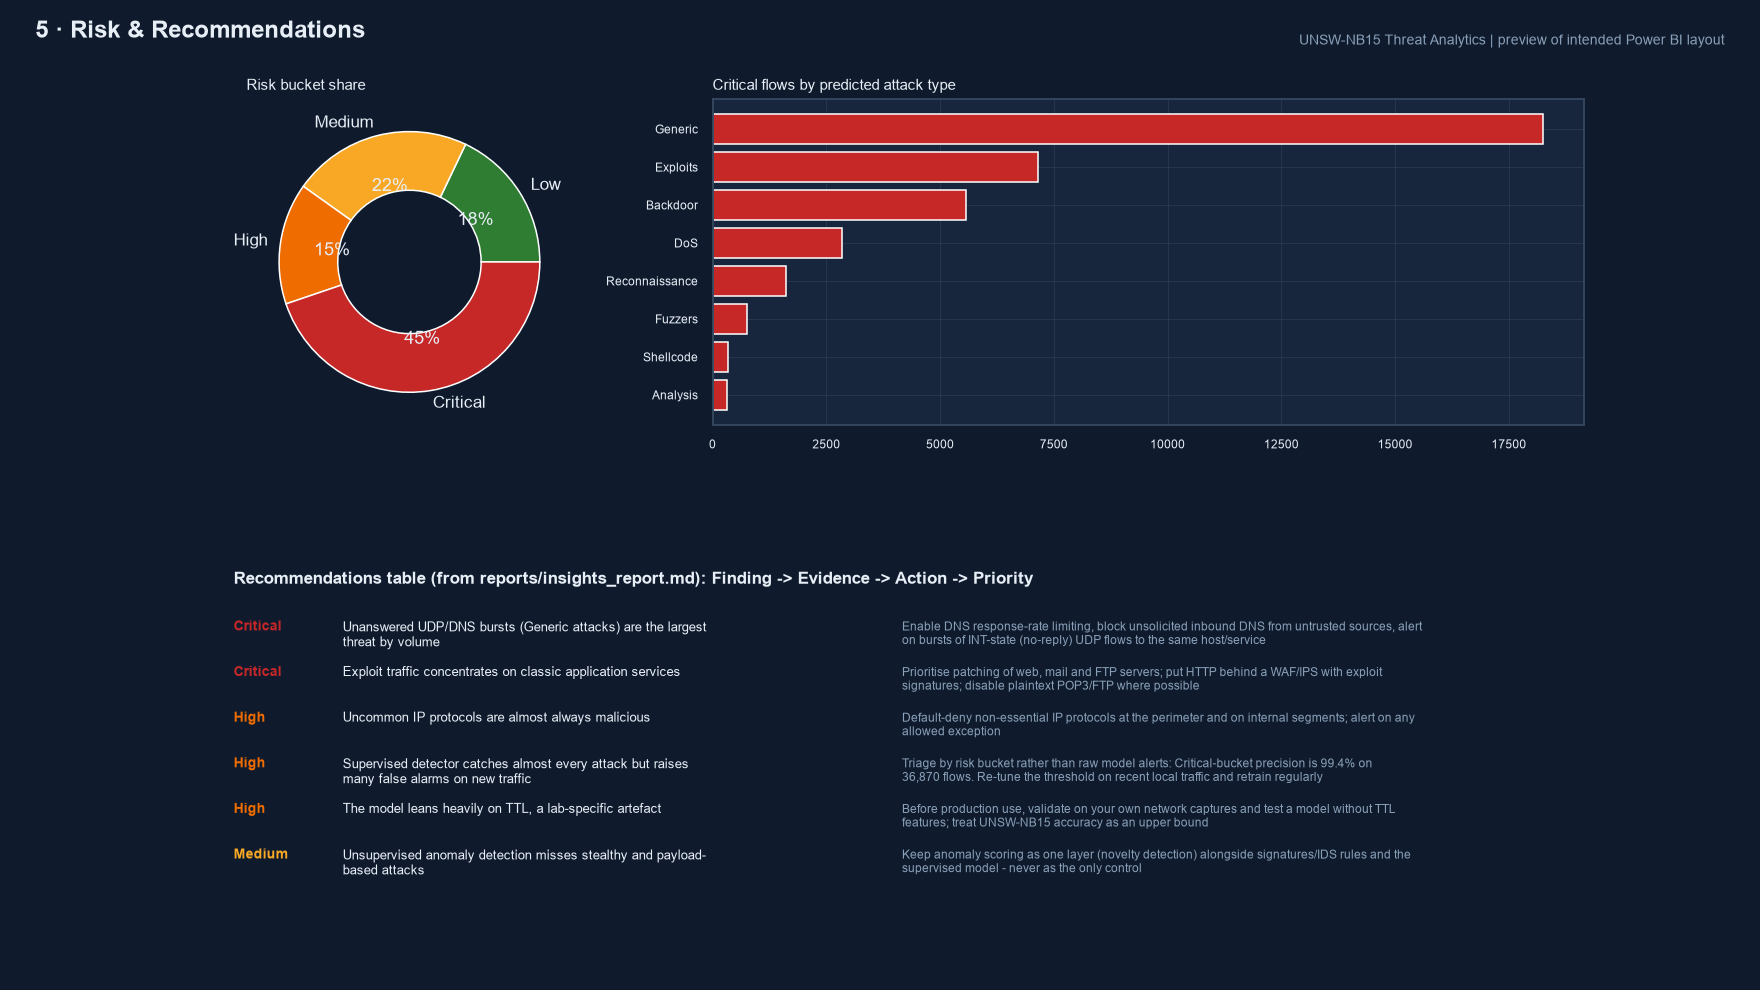

In [6]:
import powerbi
_ = powerbi.run()
from config import PREVIEW_DIR
for p in sorted(PREVIEW_DIR.glob('*.png')):
    display(Image(filename=str(p), width=1000))